<div style="padding:28px 34px;border-radius:16px;background:#6b1730;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Module 1 · Notebook 3</div><h1 style="margin:7px 0">A Linked Implementation of the List ADT</h1><p style="margin:0;font-size:1.12em">Same contract, different representation and different engineering trade-offs.</p></div>

## Recall: the list owns the chain

A singly linked list stores elements in nodes. Each node contains data and a reference to the next node; the list object owns the entry reference (`head`), the logical size, and the operations that preserve the structure.

Important invariant: starting from `head` and following `next` must visit exactly the list’s elements, in order, and eventually reach `null`. Client code should never manipulate loose nodes or rewrite links directly.

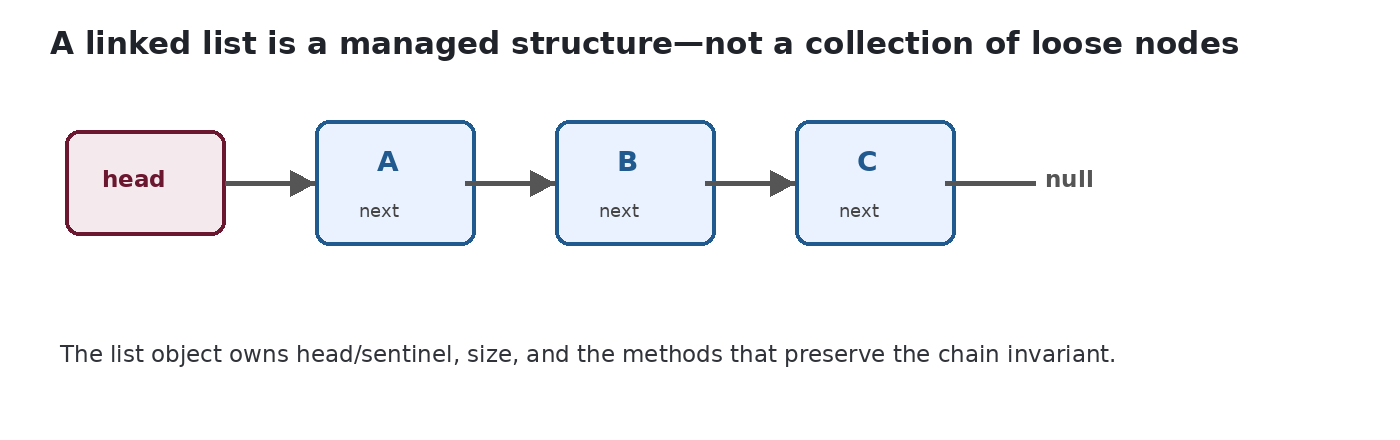

## The familiar operations—and their costs

- `addFirst`: replace `head` → O(1)
- `get(index)`: walk from the beginning → O(n)
- `addLast`: O(n) without a tail reference; O(1) with one
- remove after a known predecessor: redirect one link → O(1)
- find a value or position: traversal → O(n)

Unlike an array, linked nodes are not contiguous. Each node adds reference/object overhead, and traversal has weaker cache locality. The benefit is structural flexibility: links can change without shifting every later element.

<div style="padding:28px 34px;border-radius:16px;background:#215a8e;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Java design question</div><h1 style="margin:7px 0">What type should a node store?</h1><p style="margin:0;font-size:1.12em">The representation should be reusable without giving up compiler checks.</p></div>

## Three node designs

```java
// 1. Type-specific: safe, but duplicated for every element type
class StringNode { String data; StringNode next; }

// 2. Object-based: reusable, but requires casts and moves mistakes to runtime
class ObjectNode { Object data; ObjectNode next; }

// 3. Generic: reusable and type-safe
class Node<T> { T data; Node<T> next; }
```

Generics express “the list works for one element type chosen by the client.” `Node<String>` and `Node<Integer>` reuse the same class, while assignments of the wrong type fail during compilation. Primitive values use wrapper types such as `Integer` through autoboxing.

Notebook 2 wrote the List ADT as an `interface` with `String` fixed as the element type. With generics we can state that same contract once, for any element type `T`, and let each linked node carry a `T`. That generic contract is the next cell.

## The same contract, parameterized

Nothing about the List ADT actually depends on `String`: `add`, `get`, `remove`, `size`, and `isEmpty` describe the same observable behavior for any element type. Generics let us write the contract once and let the client choose the type at the point of use.

`SimpleList<T>` below is the Notebook 2 interface with `String` replaced by a type parameter `T`. The operations, the valid index ranges, and the failure conditions are unchanged — only the element type moved from fixed to chosen-by-the-client.

In [ ]:
%%writefile SimpleList.java
public interface SimpleList<T> {
    void add(T item);
    void add(int index, T item);
    T get(int index);
    T remove(int index);
    int size();
    boolean isEmpty();
}

## A drop-in replacement

The variable type is still the interface; only the constructor changes:

```java
SimpleList<String> names = new LinkedSimpleList<>();   // was: new ArraySimpleList<>()
names.add("Amina");
names.add(0, "Ben");
String first = names.get(0);
```

Every client written against `SimpleList<T>` compiles and runs unchanged. What differs is the cost profile, not the behavior:

| Operation | `ArraySimpleList` | `LinkedSimpleList` |
|---|---|---|
| `add(item)` (append) | O(1) amortized | O(n) — walks to the last node |
| `add(0, item)` (insert at front) | O(n) — shifts every element | O(1) |
| `get(index)` | O(1) | O(n) |
| `remove(index)` | O(n) — shift | O(n) — walk |
| per-element memory | one array slot, plus slack | one node object, plus one reference |

The linked version removes the resize latency spike and makes front insertion cheap; it gives up O(1) indexed access. `add(item)` is O(n) here only because this first version keeps no tail reference — the next section fixes exactly that.

<div style="padding:16px 20px;border-left:6px solid #c98a24;background:#f7f8fa;border-radius:8px;font-family:Arial,sans-serif"><b>Treat this as a small project</b><br><code>LinkedSimpleList</code> implements the ADT and stops there. A working list class also needs <code>contains</code>, <code>indexOf</code>, iteration, <code>equals</code>/<code>hashCode</code>, and tests. Those belong in a normal <code>.java</code> file, not more notebook cells: easier to compile, test, and change.</div>

## Notice the representation-driven special cases

Three methods in `LinkedSimpleList` branch on position:

- `add(item)` handles `head == null` separately — with no existing node, there is nothing to walk from.
- `add(0, item)` and `remove(0)` rewrite `head` itself, while every other index rewrites some `prev.next`.

Each branch is cheap to run. The cost is in maintenance: the empty, first-element, and interior cases are written and evolved separately, and that is where boundary-case defects appear. This is not a complexity problem; it is an **invariant and maintainability** problem. One standard fix — the sentinel node — appears below, among the other design refinements.

<div style="padding:28px 34px;border-radius:16px;background:#8a5a13;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Further design choices</div><h1 style="margin:7px 0">Linked list is a family, not one fixed design</h1><p style="margin:0;font-size:1.12em">Each extra reference or invariant buys a specific capability.</p></div>

## Tail reference

Store both `head` (or sentinel) and `tail`.

- Changes append from O(n) traversal to O(1).
- Adds another invariant: `tail` must always identify the last real node.
- Emptying the list must update both ends correctly.

This is valuable for queues, streaming buffers, and workloads dominated by append. It is unnecessary state if the structure only pushes and pops at the front.

## Doubly linked nodes

Each node stores both `next` and `prev`.

- Enables backward traversal.
- Removes a known node in O(1) without searching for its predecessor.
- Supports efficient operations at both ends when combined with head/tail sentinels.
- Costs one additional reference per node and requires every update to maintain two directions.

Real uses include deques, LRU-cache ordering, browser history, and intrusive scheduling lists. The gain matters when code already holds a node/reference/iterator; finding that node is still O(n).

## Sentinel (dummy) node

A **sentinel** (or dummy) node is a permanent structural node that holds no user element. `head` always points at it, so the list is never structurally “without a first node”: the first real element is always `sentinel.next`, and every insertion or removal — including at position 0 — acts through a predecessor node that is guaranteed to exist.

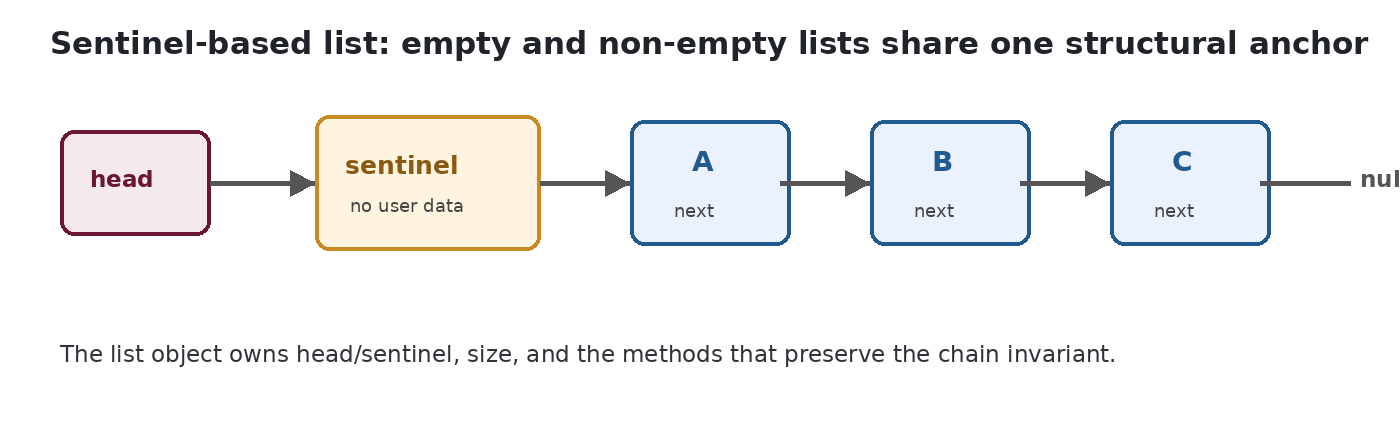

This deletes the boundary branches from the previous section:

- empty and non-empty updates share one link pattern;
- `add(0, …)` and `remove(0)` stop being special — they operate through the sentinel like any other position;
- fewer branches mean fewer boundary-case defects, and the invariant is easier to state, test, and review.

Cost: one extra node per list, plus the discipline never to expose or count it as user data — `size` must not include it, and it must never be returned. Paired with a **tail sentinel**, a doubly linked list gets O(1) insertion and removal at both ends with no special-casing at either. That is the design `java.util.LinkedList` uses.

## Circular and other designs

- **Circular list:** the last node links back to the first/sentinel. Useful for round-robin scheduling and repeated cycling, but termination conditions require care.
- **Unrolled linked list:** each node stores a small block of elements. More complex, but improves cache locality and reduces per-element pointer overhead.
- **Immutable/persistent list:** updates create new structural paths instead of mutating existing nodes. Useful for safe sharing and versioned state, with different allocation costs.

These are engineering responses to workload and system constraints—not decorative variations.

<div style="padding:28px 34px;border-radius:16px;background:#215a8e;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Standard library</div><h1 style="margin:7px 0">java.util.LinkedList</h1>

## Using it

```java
import java.util.LinkedList;

LinkedList<String> jobs = new LinkedList<>();        // empty
LinkedList<String> copy = new LinkedList<>(jobs);    // from any Collection

jobs.add("build");          // append at the end
jobs.addFirst("checkout");  // prepend
jobs.addLast("test");       // append, stated explicitly
jobs.getFirst();            // read either end without removing
jobs.getLast();
jobs.removeFirst();         // remove from either end
jobs.removeLast();

for (String job : jobs) { /* forward iteration */ }
```

`LinkedList<T>` also supplies the queue and deque verbs — `offer`, `poll`, `peek`, `push`, `pop` — used in the next two sections.

## Why it is built this way

- **Doubly linked, with head and tail references.** Every operation at either end is O(1): `addFirst`, `addLast`, `removeFirst`, `removeLast`. This is the *tail reference* and *doubly linked* refinements above, combined into one class.
- **It implements both `List` and `Deque`.** As a `List` it has positional methods (`get(index)`, `add(index, …)`); as a `Deque` it has end methods. The positional methods are still **O(n)** — `get(index)` walks in from the nearer end — so `LinkedList` is a poor choice when the workload does indexed access. Its value is O(1) work at the ends and element references that stay valid across insertions and removals elsewhere.
- **Practical guidance.** For a general-purpose list, `ArrayList` is the default: better cache locality, less memory per element, O(1) indexed access. Reach for `LinkedList` when the workload is dominated by adding and removing at the ends, or when you specifically need the `List` view of a deque. If you only need a stack or a queue, prefer `ArrayDeque` (next sections) over both.

<div style="padding:28px 34px;border-radius:16px;background:#287a55;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Abstract data type</div><h1 style="margin:7px 0">Stack</h1><p style="margin:0;font-size:1.12em">One end, last in first out.</p></div>

## What a stack is

A **stack** is a sequence with all access at one end, the *top*. The contract is deliberately restricted, and the restriction is what makes stack code easy to reason about.

Core operations, all O(1):

- `push(item)` — add to the top
- `pop()` — remove and return the top; fails on an empty stack
- `peek()` — return the top without removing it
- `isEmpty()`, `size()`

Typical uses: undo/redo, bracket and expression matching, the call stack itself, and depth-first / backtracking search — anywhere the most recently seen item is the next one to handle.

## The stack ADT

```java
public interface Stack<T> {
    void push(T item);
    T pop();
    T peek();
    boolean isEmpty();
    int size();
}
```

## Implementation choices

- **Array-backed.** Elements live in a growable array; `push` and `pop` act at the high-index end. `push` is **O(1) amortized** — the same resize argument as Notebook 2 — with good cache locality and low per-element overhead. The costs are an occasional resize copy and possibly some unused capacity.
- **Linked-backed.** A singly linked list with `push` and `pop` at the head. Every `push` is **O(1) worst-case** with no resize, at the cost of a node object plus a reference per element and weaker locality.
- Choose array-backed unless you must rule out the resize latency spike, or the maximum size is large and unpredictable enough that reserved capacity is a problem.

## Using a stack in Java

Do **not** use `java.util.Stack`. It is a legacy class that extends `Vector`: every operation is synchronized (overhead you rarely want), and because it is a `List` subclass it also exposes indexed access and iteration in insertion order, which leaks past the LIFO abstraction. Its own Javadoc says the `Deque` implementations “should be used in preference to this class.”

Use an `ArrayDeque` as the stack:

```java
import java.util.ArrayDeque;
import java.util.Deque;

Deque<Integer> stack = new ArrayDeque<>();
stack.push(1);
stack.push(2);
stack.peek();     // 2
stack.pop();      // 2
stack.isEmpty();
```

`Deque` is the interface; `ArrayDeque` is the array-backed implementation, and it is faster and lighter than both `java.util.Stack` and `LinkedList` for this purpose. One caveat: `ArrayDeque` rejects `null` elements.

<div style="padding:28px 34px;border-radius:16px;background:#287a55;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Abstract data type</div><h1 style="margin:7px 0">Queue</h1><p style="margin:0;font-size:1.12em">Two ends, first in first out.</p></div>

## What a queue is

A **queue** adds at one end (the *back*) and removes from the other (the *front*), so elements leave in arrival order — first in, first out.

Core operations, all O(1):

- `offer(item)` — add at the back
- `poll()` — remove and return the front; returns `null` when empty
- `peek()` — return the front without removing it
- `isEmpty()`, `size()`

Typical uses: task and request scheduling, buffering between a producer and a consumer, breadth-first search, and fair resource sharing.

## The queue ADT

```java
public interface Queue<T> {
    void offer(T item);
    T poll();
    T peek();
    boolean isEmpty();
    int size();
}
```

## Implementation choices

- **Linked, with head *and* tail references.** `offer` links after `tail`, `poll` unlinks after `head`; both O(1) worst-case. This is precisely why the *tail reference* refinement exists — a singly linked list with only a `head` makes one of the two operations O(n). Cost: a node and a reference per element.
- **Circular array (ring buffer).** A fixed array with `front` and `back` indices that wrap with `%`. O(1) amortized operations, excellent locality, low overhead; grows by resize when full. This is what `ArrayDeque` does internally.
- **Bounded vs. growable.** A fixed-capacity ring buffer gives predictable memory and can push back when full — often what you want between a fast producer and a slow consumer. A growable queue is easier on callers but can hide an unbounded backlog.
- **Concurrency.** A queue passing work from producer threads to consumer threads needs a thread-safe implementation — `ConcurrentLinkedQueue`, or a `BlockingQueue` such as `ArrayBlockingQueue` / `LinkedBlockingQueue` — not a plain `ArrayDeque` guarded by hand.

A **priority queue** removes the *highest-priority* element rather than the oldest. That is a different contract, backed by a heap, and is covered later in the course.

## Using a queue in Java

```java
import java.util.ArrayDeque;
import java.util.Queue;

Queue<String> tasks = new ArrayDeque<>();
tasks.offer("first");
tasks.offer("second");
tasks.peek();     // "first"
tasks.poll();     // "first"
tasks.isEmpty();
```

`ArrayDeque` is the default single-threaded queue: faster and lighter than `LinkedList`, which also implements `Queue` but adds a node object per element. Use `LinkedList` only when you also need the `List` view. As with the stack, `ArrayDeque` forbids `null` — which is why `poll` and `peek` use `null` as the “empty” signal, and callers must never enqueue it.

<div style="padding:28px 34px;border-radius:16px;background:#6b1730;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Engineering decision</div><h1 style="margin:7px 0">Choose behavior first, representation second</h1><p style="margin:0;font-size:1.12em">Data-structure selection is a two-stage design decision.</p></div>

## Question 1: Which ADT matches the problem?

Start from the operations the application actually needs, and decide which contract fits:

- **Sequence (List):** elements kept in a client-controlled order, addressed by position; insertion and removal at any position.
- **Stack:** all access at one end; last in, first out.
- **Queue:** add at one end, remove at the other; first in, first out.

Then pin down: are duplicates allowed or must elements be unique; is any ordering guarantee required; how must the operations fail (exception, sentinel value, block); and do multiple threads touch the structure.

Do not choose “linked list” or “array” yet. First decide whether you need a sequence, a stack, or a queue. (Richer contracts exist and are covered later in the course.)

## Question 2: Which implementation fits the workload?

Once the contract is fixed, weigh implementations against four things:

- **Dominant operations.** Which calls happen most, and *where* — at the ends, at arbitrary positions, or by index? Match the implementation’s O(1) operations to that hot path. (Indexed access → array; ends-only churn → linked or ring buffer; front insertion → linked.)
- **Latency shape.** Is the target average, amortized, or worst-case? Amortized-O(1) structures (a resizing array, `ArrayDeque`) pay with occasional resize spikes; a linked structure has no spike but a higher constant per operation.
- **Memory and locality.** Per-element overhead (a bare slot vs. a node object and one or two references), tolerance for unused capacity, and whether scans need to be cache-friendly.
- **Invariants and risk.** Every extra reference — `tail`, `prev`, a sentinel — is another invariant to keep true under every update. Weigh that maintenance cost, testability, and any concurrency requirement.

There is no universally “best” implementation — only the best-supported decision for a particular workload and set of constraints.

## Exercise: design decisions in the wild

Each scenario describes a system without naming a data structure. For each one:

1. Decide which contract from this notebook fits best — **sequence, stack, or queue** — and, where it matters, which backing implementation (array / ring buffer / singly or doubly linked, with or without a tail reference...).
2. In your own words, justify the implementation you would choose. Name the operation that dominates the workload, explain why your choice keeps that operation cheap, and say what you give up.

Each scenario has a defensible best answer, but more than one choice can be argued. Write the argument, not just the label.

---

**Scenario 1 — Editor history.**
A desktop document editor lets a user reverse their most recent editing actions one at a time, and re-apply actions they have reversed. History is capped at 100 actions; performing a fresh action after some reversals discards the re-apply trail. Each action record carries a document diff and can be large, and the editor targets low-end laptops. A side panel lists the descriptions of the last several actions, newest first, and the user can scroll it.

**Scenario 2 — Lab print server.**
A shared print server accepts jobs from many lab machines and releases them to a single printer in the order received. An administrator console shows the current backlog and can cancel a specific still-waiting job by its id. At peak, several hundred jobs are waiting; each job is a small metadata record that points at a spooled file.

**Scenario 3 — Playlist.**
A music app lets a user append songs to a playlist, drag a song from one position to another, and delete songs; the player then walks the playlist from top to bottom. Playlists are usually 20–200 songs, but some users have more than 5,000. The screen shows about 30 rows at a time and must fetch “the song at scroll offset k” quickly while the user drags the scrollbar.

## Check your understanding

1. Why should `Node` stay a private, nested detail of the list rather than something client code touches?
2. What does `LinkedSimpleList<T>` gain from a type parameter that an `Object`-based node would lose?
3. Which operations favor linked storage, and which favor array storage?
4. In `LinkedSimpleList`, which methods special-case position 0 or the empty list, and how does a sentinel node remove those cases? What does the sentinel cost?
5. What does a tail reference buy a linked queue, and what new invariant does it add?
6. `java.util.LinkedList` implements `List`. Why is it still a poor choice for a loop that calls `get(index)`?
7. Why is `ArrayDeque` preferred over `java.util.Stack` for a new stack, and what can `ArrayDeque` not store?
8. State the two questions, in order, that should precede choosing a data-structure implementation.